## Customer Purchase Behavior Analysis



**Dataset:** Cust_Purch_FakeData.csv  
**Records:** 30,000

This notebook performs:

- Data preprocessing
- Descriptive statistics
- Hypothesis testing
- Correlation analysis
- Regression analysis
- Data visualization

In [2]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from matplotlib.gridspec import GridSpec
from scipy import stats

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

# Load Dataset

The dataset is loaded using pandas.

In [3]:
# Load Dataset

df = pd.read_csv("C:\\Users\\IT GADGETS\\OneDrive\\Documents\\Cust_Purch_FakeData.csv")

print("Dataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

Dataset Shape:
(30000, 20)

Columns:
['prefix', 'first', 'last', 'email', 'gender', 'age', 'company', 'profession', 'phone', 'postal', 'province', 'cc_no', 'cc_exp', 'cc_type', 'price(CAD)', 'fav_color', 'ip', 'weekday', 'ampm', 'date']


# Dataset Information

Checking data types and structure.

In [4]:
df

,prefix,first,last,email,gender,age,company,profession,phone,postal,province,cc_no,cc_exp,cc_type,price(CAD),fav_color,ip,weekday,ampm,date
0,Dr.,Ray,Morton,sebvajom@kol.km,Male,38,Medtronic Inc.,Health Therapist,(987) 619-2695,B6V 3W3,MB,5.020000e+15,May-18,Solo,8.36,Blue,126.23.139.2,Sunday,pm,4/5/1930
1,Miss,Claudia,Rodriquez,acu@jatsot.ug,Female,51,"Ames Department Stores, Inc.",Health Therapist,(356) 736-7352,G7M 5F3,SK,5.020000e+15,Jul-28,Visa,68.31,Black,106.198.76.211,Tuesday,am,12/20/1926
2,Miss,Harry,Meyer,zuz@lo.wf,Female,51,CSX Corp.,Political Scientist,(539) 246-1806,A0Z 6P9,NS,6.300000e+15,Feb-23,Switch,34.65,Black,186.150.187.29,Wednesday,pm,8/20/1931
3,Miss,Edith,Gilbert,hansohsi@jupec.md,Female,55,Murphy Oil Corporation,Transportation Manager,(984) 962-7494,P9I 9H3,YT,3.530000e+15,Feb-28,Maestro,64.59,White,80.140.57.161,Saturday,am,6/18/2001
4,Dr.,Lura,Murphy,webediti@je.st,Female,20,PETsMART Inc,Statistician,(902) 568-9748,S1A 6K0,ON,4.030000e+15,Oct-25,Diners Club International,20.83,Yellow,211.103.43.41,Friday,pm,6/14/2045
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,Mr.,John,Maxwell,larlisu@sejenu.ad,Female,38,Spherion Corp,Publishing Director,(873) 298-1178,V4U 0X2,YT,6.330000e+15,Apr-28,Visa Electron,90.37,Red,194.14.119.109,Sunday,am,4/18/2014
29996,Dr.,Alfred,Bass,le@duridzo.gh,Female,24,Ford Motor Co,Diamond Merchant,(541) 904-3323,T9O 1H6,PE,2.010000e+14,Dec-26,American Express,5.94,White,154.114.74.254,Sunday,pm,9/27/2068
29997,Mrs.,Edward,Curtis,ta@kucemah.et,Female,56,Park Place Entertainment Corp,Executive Director,(375) 931-8605,X5Z 4E1,QC,2.010000e+14,Jun-21,Maestro,65.66,Black,188.0.106.220,Monday,pm,9/7/1997
29998,Mr.,Max,Woods,li@mincoz.mp,Female,64,Nacco Industries Inc,University Administrator,(786) 481-9627,G0S 9Q8,NS,3.000000e+13,Aug-23,Solo,52.66,Black,129.168.247.27,Monday,pm,9/8/1938


In [47]:
# Dataset Information

print(df.dtypes)

prefix         object
first          object
last           object
email          object
gender         object
age             int64
company        object
profession     object
phone          object
postal         object
province       object
cc_no         float64
cc_exp         object
cc_type        object
price(CAD)    float64
fav_color      object
ip             object
weekday        object
ampm           object
date           object
dtype: object


# Data Cleaning and Preprocessing

This section checks:

- Missing values
- Duplicate records
- Feature engineering

In [48]:
# Missing Values

print(df.isnull().sum())

prefix        0
first         0
last          0
email         0
gender        0
age           0
company       0
profession    0
phone         0
postal        0
province      0
cc_no         0
cc_exp        0
cc_type       0
price(CAD)    0
fav_color     0
ip            0
weekday       0
ampm          0
date          0
dtype: int64


In [49]:
# Duplicate Rows

print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


# Feature Engineering

Creating:

- Age groups
- Weekend indicator
- Price quartiles

In [50]:
# Age Group

df['age_group'] = pd.cut(
    df['age'],
    bins=[17, 25, 35, 45, 55, 65],
    labels=['18-25', '26-35', '36-45', '46-55', '56-65']
)

# Weekend Indicator

df['is_weekend'] = df['weekday'].isin(['Saturday', 'Sunday'])

# Price Quartiles

df['price_quartile'] = pd.qcut(
    df['price(CAD)'],
    q=4,
    labels=['Q1', 'Q2', 'Q3', 'Q4']
)

print(df.head())

  prefix    first       last              email  gender  age  \
0    Dr.      Ray     Morton    sebvajom@kol.km    Male   38   
1   Miss  Claudia  Rodriquez      acu@jatsot.ug  Female   51   
2   Miss    Harry      Meyer          zuz@lo.wf  Female   51   
3   Miss    Edith    Gilbert  hansohsi@jupec.md  Female   55   
4    Dr.     Lura     Murphy     webediti@je.st  Female   20   

                        company              profession           phone  \
0                Medtronic Inc.        Health Therapist  (987) 619-2695   
1  Ames Department Stores, Inc.        Health Therapist  (356) 736-7352   
2                     CSX Corp.     Political Scientist  (539) 246-1806   
3        Murphy Oil Corporation  Transportation Manager  (984) 962-7494   
4                  PETsMART Inc            Statistician  (902) 568-9748   

    postal  ...                    cc_type  price(CAD) fav_color  \
0  B6V 3W3  ...                       Solo        8.36      Blue   
1  G7M 5F3  ...             

# Descriptive Statistics

Summary statistics of numerical variables.

In [51]:
# Descriptive Statistics

print(df[['age', 'price(CAD)']].describe())

                age    price(CAD)
count  30000.000000  30000.000000
mean      41.550067     49.990775
std       13.839073     28.768666
min       18.000000      0.000000
25%       30.000000     25.345000
50%       42.000000     49.970000
75%       53.000000     74.942500
max       65.000000    100.000000


# Gender Distribution

In [52]:
# Gender Distribution

print(df['gender'].value_counts())

gender
Female    15147
Male      14853
Name: count, dtype: int64


# Credit Card Type Distribution

In [53]:
# Credit Card Types

print(df['cc_type'].value_counts())

cc_type
Solo                                  1867
Visa Electron                         1815
American Express                      1810
Switch                                1806
Laser                                 1798
China UnionPay                        1788
Diners Club enRoute                   1758
Maestro                               1756
JCB                                   1751
Diners Club United States & Canada    1746
Diners Club International             1745
Mastercard                            1741
Discover Card                         1739
Diners Club Carte Blanche             1732
Bankcard                              1728
Visa                                  1721
InstaPayment                          1699
Name: count, dtype: int64


# Province Distribution

In [54]:
# Province Distribution

print(df['province'].value_counts().head(10))

province
ON    2372
NU    2350
MB    2338
SK    2335
AB    2325
NL    2320
YT    2308
QC    2308
NT    2300
BC    2299
Name: count, dtype: int64


# Hypothesis Testing

This section performs:

- T-Test
- Chi-Square Test
- ANOVA
- Correlation
- Regression

# T-Test: Gender vs Purchase Price

In [55]:
# Gender vs Price

male_price = df[df['gender'] == 'Male']['price(CAD)']
female_price = df[df['gender'] == 'Female']['price(CAD)']

t1, p1 = stats.ttest_ind(male_price, female_price)

print("Male Mean:", male_price.mean())
print("Female Mean:", female_price.mean())

print("t-statistic:", t1)
print("p-value:", p1)

Male Mean: 50.042677573554165
Female Mean: 49.93987984419357
t-statistic: 0.3094332872005842
p-value: 0.7569941016520694


# T-Test: AM vs PM Purchase Price

In [56]:
# AM vs PM

am_price = df[df['ampm'] == 'am']['price(CAD)']
pm_price = df[df['ampm'] == 'pm']['price(CAD)']

t2, p2 = stats.ttest_ind(am_price, pm_price)

print("AM Mean:", am_price.mean())
print("PM Mean:", pm_price.mean())

print("t-statistic:", t2)
print("p-value:", p2)

AM Mean: 49.96033796819906
PM Mean: 50.02133809873739
t-statistic: -0.18362582196088043
p-value: 0.8543082456479261


# Chi-Square Test

Testing association between:

- Gender
- Credit Card Type

In [57]:
# Chi-Square Test

top_cc = df['cc_type'].value_counts().head(4).index

df_cc = df[df['cc_type'].isin(top_cc)]

ct = pd.crosstab(
    df_cc['gender'],
    df_cc['cc_type']
)

chi2, p_chi, dof, expected = stats.chi2_contingency(ct)

print("Chi-square:", chi2)
print("Degrees of Freedom:", dof)
print("p-value:", p_chi)

Chi-square: 0.82985619191262
Degrees of Freedom: 3
p-value: 0.8423132991849573


# One-Way ANOVA

Comparing purchase price across age groups.

In [58]:
# ANOVA

groups = [
    df[df['age_group'] == g]['price(CAD)']
    for g in df['age_group'].cat.categories
]

f_stat, p_anova = stats.f_oneway(*groups)

print("F-statistic:", f_stat)
print("p-value:", p_anova)

F-statistic: 3.2020531551996925
p-value: 0.012264162560128805


# Pearson Correlation

Relationship between:

- Age
- Purchase Price

In [59]:
# Pearson Correlation

r, p_corr = stats.pearsonr(
    df['age'],
    df['price(CAD)']
)

print("Correlation:", r)
print("p-value:", p_corr)

Correlation: 0.01044666793009862
p-value: 0.07039044550764234


# Linear Regression

Predicting purchase price using customer age.

In [60]:
# Linear Regression

slope, intercept, r_val, p_reg, std_err = stats.linregress(
    df['age'],
    df['price(CAD)']
)

print("Slope:", slope)
print("Intercept:", intercept)
print("R-squared:", r_val**2)

Slope: 0.0217165337975538
Intercept: 49.088451572942716
R-squared: 0.00010913287084175108


# Figure 1 — Descriptive & Inferential Visualizations

This figure contains:

1. Purchase Price Distribution  
2. Customer Age Distribution  
3. Gender Distribution  
4. Price by Gender  
5. Mean Price by Age Group  
6. Top Credit Card Types  
7. Transactions by Weekday  
8. Age vs Purchase Price  
9. AM vs PM Purchase Price

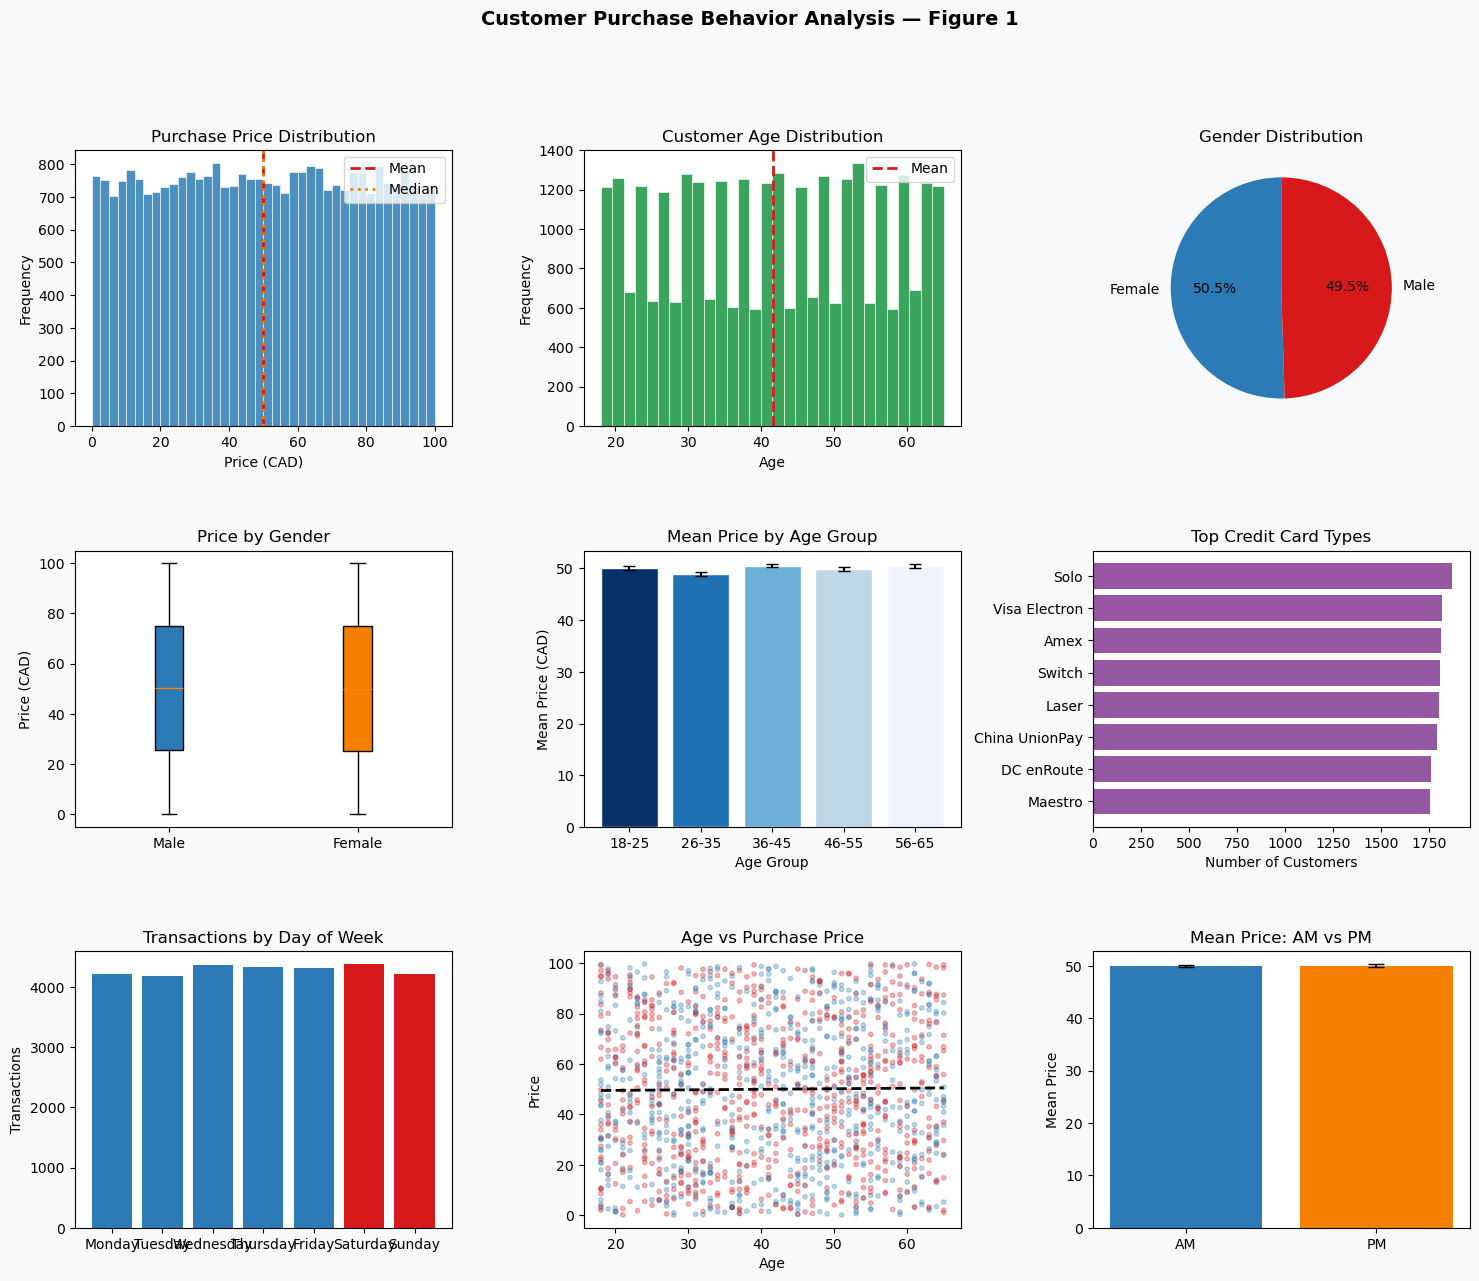

In [61]:
# ============================================================
# FIGURE 1 — DESCRIPTIVE & INFERENTIAL VISUALIZATIONS
# ============================================================

fig = plt.figure(figsize=(18, 14))

fig.patch.set_facecolor('#F8F9FA')

gs = GridSpec(
    3,
    3,
    figure=fig,
    hspace=0.45,
    wspace=0.35
)

blue_palette = [
    '#08306B',
    '#2171B5',
    '#6BAED6',
    '#BDD7E7',
    '#EFF3FF'
]

# ------------------------------------------------------------
# Panel 1 — Price Distribution
# ------------------------------------------------------------

ax1 = fig.add_subplot(gs[0, 0])

ax1.hist(
    df['price(CAD)'],
    bins=40,
    color='#2C7BB6',
    edgecolor='white',
    linewidth=0.5,
    alpha=0.85
)

ax1.axvline(
    df['price(CAD)'].mean(),
    color='#D7191C',
    linewidth=2,
    linestyle='--',
    label='Mean'
)

ax1.axvline(
    df['price(CAD)'].median(),
    color='#F77F00',
    linewidth=2,
    linestyle=':',
    label='Median'
)

ax1.set_title('Purchase Price Distribution')
ax1.set_xlabel('Price (CAD)')
ax1.set_ylabel('Frequency')

ax1.legend()

# ------------------------------------------------------------
# Panel 2 — Age Distribution
# ------------------------------------------------------------

ax2 = fig.add_subplot(gs[0, 1])

ax2.hist(
    df['age'],
    bins=30,
    color='#1A9641',
    edgecolor='white',
    linewidth=0.5,
    alpha=0.85
)

ax2.axvline(
    df['age'].mean(),
    color='#D7191C',
    linewidth=2,
    linestyle='--',
    label='Mean'
)

ax2.set_title('Customer Age Distribution')

ax2.set_xlabel('Age')
ax2.set_ylabel('Frequency')

ax2.legend()

# ------------------------------------------------------------
# Panel 3 — Gender Distribution
# ------------------------------------------------------------

ax3 = fig.add_subplot(gs[0, 2])

gender_counts = df['gender'].value_counts()

ax3.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct='%1.1f%%',
    colors=['#2C7BB6', '#D7191C'],
    startangle=90
)

ax3.set_title('Gender Distribution')

# ------------------------------------------------------------
# Panel 4 — Price by Gender
# ------------------------------------------------------------

ax4 = fig.add_subplot(gs[1, 0])

bp = ax4.boxplot(
    [male_price, female_price],
    patch_artist=True,
    labels=['Male', 'Female']
)

bp['boxes'][0].set_facecolor('#2C7BB6')
bp['boxes'][1].set_facecolor('#F77F00')

ax4.set_title('Price by Gender')

ax4.set_ylabel('Price (CAD)')

# ------------------------------------------------------------
# Panel 5 — Mean Price by Age Group
# ------------------------------------------------------------

ax5 = fig.add_subplot(gs[1, 1])

age_groups = [
    '18-25',
    '26-35',
    '36-45',
    '46-55',
    '56-65'
]

means = [
    df[df['age_group'] == g]['price(CAD)'].mean()
    for g in age_groups
]

sems = [
    df[df['age_group'] == g]['price(CAD)'].sem()
    for g in age_groups
]

bars5 = ax5.bar(
    age_groups,
    means,
    color=blue_palette,
    edgecolor='white',
    yerr=sems,
    capsize=4
)

ax5.set_title('Mean Price by Age Group')

ax5.set_xlabel('Age Group')
ax5.set_ylabel('Mean Price (CAD)')

# ------------------------------------------------------------
# Panel 6 — Top Credit Card Types
# ------------------------------------------------------------

ax6 = fig.add_subplot(gs[1, 2])

cc_counts = df['cc_type'].value_counts().head(8)

short_names = [
    name.replace('Diners Club ', 'DC ')
    .replace('American Express', 'Amex')
    for name in cc_counts.index
]

ax6.barh(
    short_names[::-1],
    cc_counts.values[::-1],
    color='#7B2D8B',
    alpha=0.8
)

ax6.set_title('Top Credit Card Types')

ax6.set_xlabel('Number of Customers')

# ------------------------------------------------------------
# Panel 7 — Transactions by Weekday
# ------------------------------------------------------------

ax7 = fig.add_subplot(gs[2, 0])

weekday_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

weekday_counts = (
    df['weekday']
    .value_counts()
    .reindex(weekday_order)
)

weekday_colors = [
    '#2C7BB6'
    if d not in ['Saturday', 'Sunday']
    else '#D7191C'
    for d in weekday_order
]

ax7.bar(
    weekday_order,
    weekday_counts.values,
    color=weekday_colors
)

ax7.set_title('Transactions by Day of Week')

ax7.set_ylabel('Transactions')

# ------------------------------------------------------------
# Panel 8 — Scatter Plot
# ------------------------------------------------------------

ax8 = fig.add_subplot(gs[2, 1])

sample = df.sample(1500, random_state=42)

colors_g = [
    '#2C7BB6'
    if g == 'Male'
    else '#D7191C'
    for g in sample['gender']
]

ax8.scatter(
    sample['age'],
    sample['price(CAD)'],
    c=colors_g,
    alpha=0.3,
    s=10
)

x_line = np.array([
    df['age'].min(),
    df['age'].max()
])

ax8.plot(
    x_line,
    slope * x_line + intercept,
    'k--',
    linewidth=2
)

ax8.set_title('Age vs Purchase Price')

ax8.set_xlabel('Age')
ax8.set_ylabel('Price')

# ------------------------------------------------------------
# Panel 9 — AM vs PM Price
# ------------------------------------------------------------

ax9 = fig.add_subplot(gs[2, 2])

ampm_means = df.groupby('ampm')['price(CAD)'].mean()

ampm_sems = df.groupby('ampm')['price(CAD)'].sem()

ax9.bar(
    ['AM', 'PM'],
    ampm_means.values,
    color=['#2C7BB6', '#F77F00'],
    yerr=ampm_sems.values,
    capsize=6
)

ax9.set_title('Mean Price: AM vs PM')

ax9.set_ylabel('Mean Price')

# ------------------------------------------------------------
# Save Figure 1
# ------------------------------------------------------------

plt.suptitle(
    'Customer Purchase Behavior Analysis — Figure 1',
    fontsize=14,
    fontweight='bold'
)

plt.savefig(
    'fig1_descriptive.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

# Figure 2 — Advanced Analytics

This figure contains:

1. Province × Age Group Heatmap  
2. Revenue by Province  
3. Gender × Weekday Analysis  
4. Violin Plot  
5. Regression Hexbin Plot

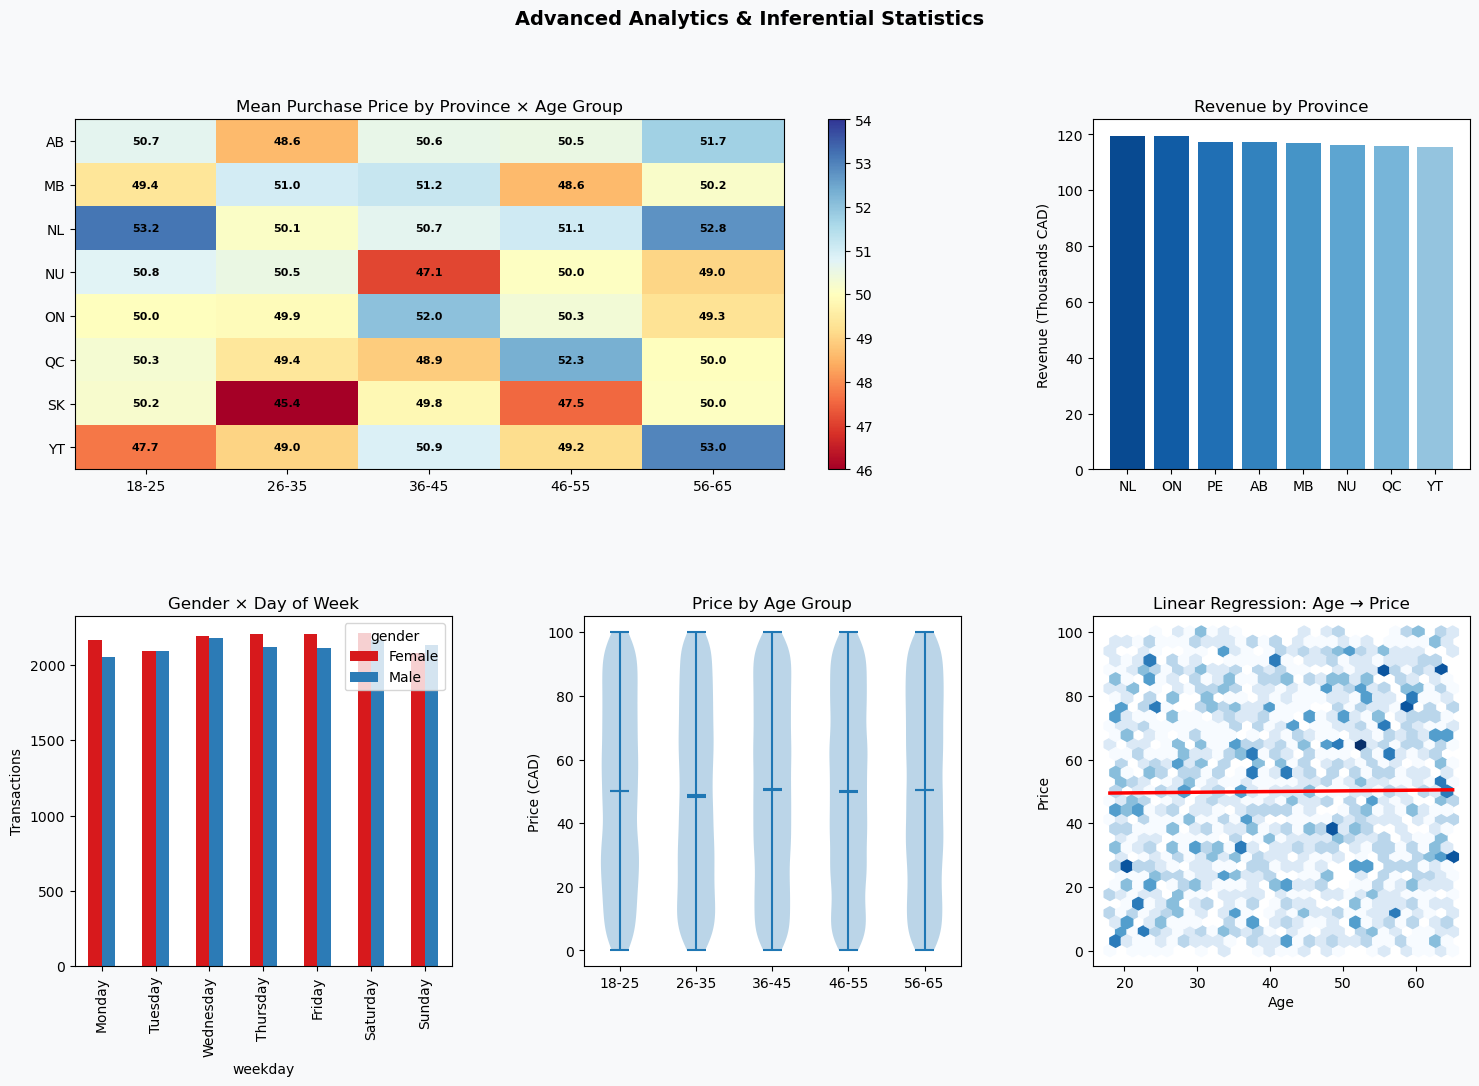

In [62]:
# ============================================================
# FIGURE 2 — ADVANCED ANALYTICS
# ============================================================

fig2_obj = plt.figure(figsize=(18, 11))

fig2_obj.patch.set_facecolor('#F8F9FA')

gs2 = GridSpec(
    2,
    3,
    figure=fig2_obj,
    hspace=0.42,
    wspace=0.35
)

# ------------------------------------------------------------
# Panel 1 — Heatmap
# ------------------------------------------------------------

ax_h1 = fig2_obj.add_subplot(gs2[0, 0:2])

top_provinces = df['province'].value_counts().head(8).index

pivot = df[df['province'].isin(top_provinces)].pivot_table(
    values='price(CAD)',
    index='province',
    columns='age_group',
    aggfunc='mean'
)

im = ax_h1.imshow(
    pivot.values,
    aspect='auto',
    cmap='RdYlBu',
    vmin=46,
    vmax=54
)

ax_h1.set_xticks(range(len(pivot.columns)))
ax_h1.set_yticks(range(len(pivot.index)))

ax_h1.set_xticklabels(pivot.columns)
ax_h1.set_yticklabels(pivot.index)

plt.colorbar(im, ax=ax_h1)

ax_h1.set_title(
    'Mean Purchase Price by Province × Age Group'
)
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        ax_h1.text(
            j,
            i,
            f'{pivot.values[i, j]:.1f}',
            ha='center',
            va='center',
            fontsize=8,
            fontweight='bold',
            color='black'
        )

# ------------------------------------------------------------
# Panel 2 — Revenue by Province
# ------------------------------------------------------------

ax_h2 = fig2_obj.add_subplot(gs2[0, 2])

prov_revenue = (
    df.groupby('province')['price(CAD)']
    .sum()
    .sort_values(ascending=False)
    .head(8)
)

colors_prov = plt.cm.Blues(
    np.linspace(0.4, 0.9, len(prov_revenue))
)[::-1]

ax_h2.bar(
    prov_revenue.index,
    prov_revenue.values / 1000,
    color=colors_prov
)

ax_h2.set_title('Revenue by Province')

ax_h2.set_ylabel('Revenue (Thousands CAD)')

# ------------------------------------------------------------
# Panel 3 — Gender × Weekday
# ------------------------------------------------------------

ax_h3 = fig2_obj.add_subplot(gs2[1, 0])

wk_gender = (
    df.groupby(['weekday', 'gender'])
    .size()
    .unstack()
    .reindex(weekday_order)
)

wk_gender.plot(
    kind='bar',
    ax=ax_h3,
    color=['#D7191C', '#2C7BB6']
)

ax_h3.set_title('Gender × Day of Week')

ax_h3.set_ylabel('Transactions')

# ------------------------------------------------------------
# Panel 4 — Violin Plot
# ------------------------------------------------------------

ax_h4 = fig2_obj.add_subplot(gs2[1, 1])

data_violin = [
    df[df['age_group'] == g]['price(CAD)'].values
    for g in age_groups
]

parts = ax_h4.violinplot(
    data_violin,
    positions=range(5),
    showmeans=True,
    showmedians=True
)

ax_h4.set_xticks(range(5))

ax_h4.set_xticklabels(age_groups)

ax_h4.set_title('Price by Age Group')

ax_h4.set_ylabel('Price (CAD)')

# ------------------------------------------------------------
# Panel 5 — Hexbin Regression Plot
# ------------------------------------------------------------

ax_h5 = fig2_obj.add_subplot(gs2[1, 2])

sample2 = df.sample(2000, random_state=1)

ax_h5.hexbin(
    sample2['age'],
    sample2['price(CAD)'],
    gridsize=30,
    cmap='Blues',
    mincnt=1
)

x_reg = np.linspace(18, 65, 100)

ax_h5.plot(
    x_reg,
    slope * x_reg + intercept,
    'r-',
    linewidth=2.5
)

ax_h5.set_title('Linear Regression: Age → Price')

ax_h5.set_xlabel('Age')

ax_h5.set_ylabel('Price')

# ------------------------------------------------------------
# Save Figure 2
# ------------------------------------------------------------

plt.suptitle(
    'Advanced Analytics & Inferential Statistics',
    fontsize=14,
    fontweight='bold'
)

plt.savefig(
    'fig2_advanced.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# Conclusion

This analysis explored customer purchase behavior using:

- Descriptive statistics
- Hypothesis testing
- ANOVA
- Correlation analysis
- Linear regression
- Advanced visualization

The generated figures provide insights into customer demographics, spending patterns, and transaction behavior.